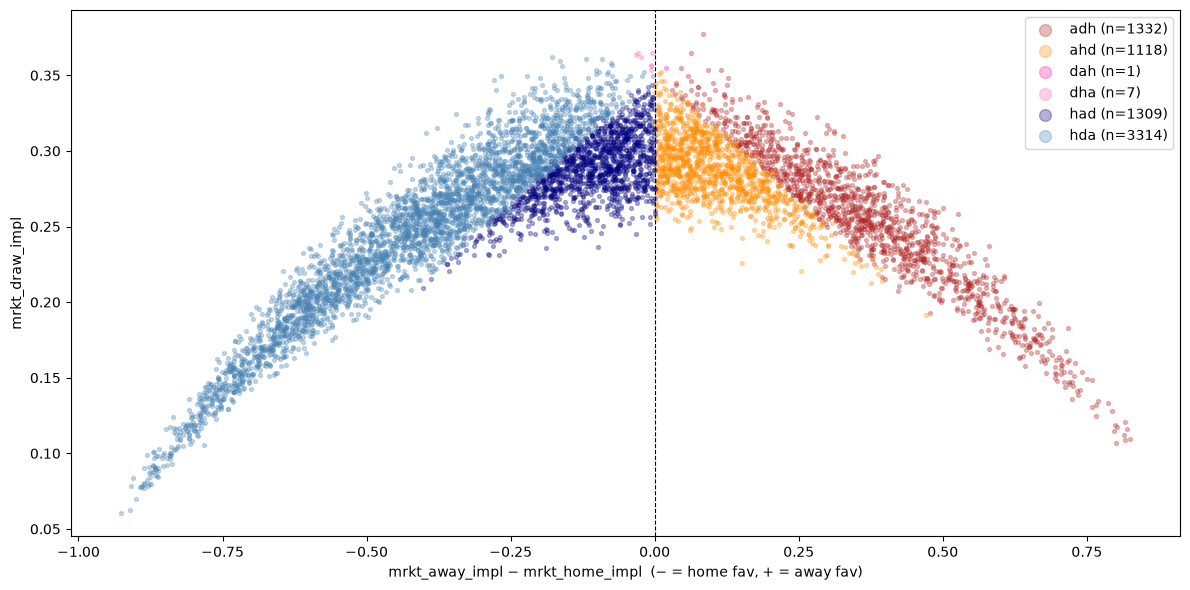

In [11]:
d = abt[['mrkt_home_impl', 'mrkt_draw_impl', 'mrkt_away_impl']].dropna().copy()

def order(row):
    s = sorted([('h', row.mrkt_home_impl), ('d', row.mrkt_draw_impl), ('a', row.mrkt_away_impl)], key=lambda x: -x[1])
    return ''.join(x[0] for x in s)

d['cat'] = d.apply(order, axis=1)
d['x'] = d['mrkt_away_impl'] - d['mrkt_home_impl']

palette = {'hda': 'steelblue',  'had': 'navy',
           'adh': 'firebrick',  'ahd': 'darkorange',
           'dha': 'hotpink',    'dah': 'deeppink'}

fig, ax = plt.subplots(figsize=(12, 6))
for cat, grp in d.groupby('cat'):
    ax.scatter(grp['x'], grp['mrkt_draw_impl'],
               c=palette[cat], label=f'{cat} (n={len(grp)})',
               alpha=0.3, s=8)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('mrkt_away_impl − mrkt_home_impl  (− = home fav, + = away fav)')
ax.set_ylabel('mrkt_draw_impl')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()


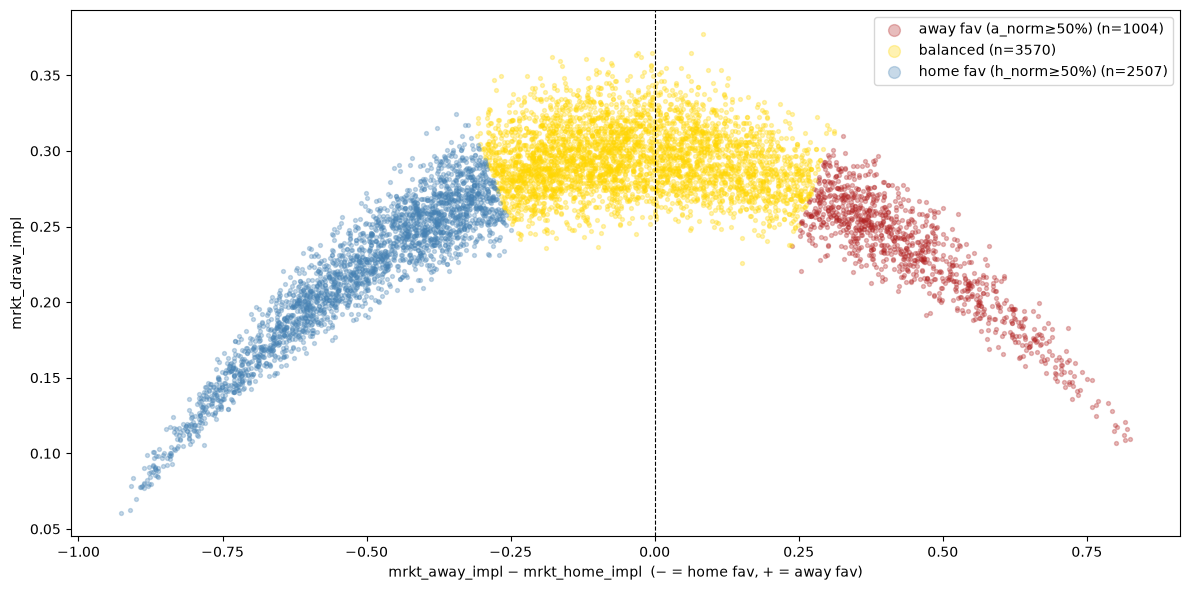

In [12]:
d = abt[['mrkt_home_impl', 'mrkt_draw_impl', 'mrkt_away_impl']].dropna().copy()

total = d['mrkt_home_impl'] + d['mrkt_draw_impl'] + d['mrkt_away_impl']
d['h_norm'] = d['mrkt_home_impl'] / total
d['a_norm'] = d['mrkt_away_impl'] / total
d['x'] = d['mrkt_away_impl'] - d['mrkt_home_impl']

def cat(row):
    if row.h_norm >= 0.5: return 'home fav (h_norm≥50%)'
    if row.a_norm >= 0.5: return 'away fav (a_norm≥50%)'
    return 'balanced'

d['cat'] = d.apply(cat, axis=1)

palette = {'home fav (h_norm≥50%)': 'steelblue',
           'away fav (a_norm≥50%)': 'firebrick',
           'balanced':              'gold'}

fig, ax = plt.subplots(figsize=(12, 6))
for cat_name, grp in d.groupby('cat'):
    ax.scatter(grp['x'], grp['mrkt_draw_impl'],
               c=palette[cat_name], label=f'{cat_name} (n={len(grp)})',
               alpha=0.3, s=8)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('mrkt_away_impl − mrkt_home_impl  (− = home fav, + = away fav)')
ax.set_ylabel('mrkt_draw_impl')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()


In [13]:
d = d.join(abt[['t_home_flg', 't_draw_flg', 't_away_flg', 't_draw_profit']])

(
    d.groupby('cat')
    .agg(
        n=('t_draw_flg', 'count'),
        home_win=('t_home_flg', 'mean'),
        draw=('t_draw_flg', 'mean'),
        away_win=('t_away_flg', 'mean'),
        draw_impl=('mrkt_draw_impl', 'mean'),
        draw_profit=('t_draw_profit', 'mean'),
    )
    .round(3)
)


,n,home_win,draw,away_win,draw_impl,draw_profit
cat,,,,,,
away fav (a_norm≥50%),1004,0.143,0.224,0.632,0.234,-0.010
balanced,3570,0.370,0.288,0.341,0.294,-0.006
home fav (h_norm≥50%),2507,0.651,0.213,0.136,0.221,-0.008


In [14]:
abt = pd.read_parquet('C:/Users/twluc/frame/01_data/03_abt/abt.parquet')
pd.crosstab(abt['mrkt_favourite'], abt['mrkt_impl_order'])


mrkt_impl_order,adh,ahd,dah,dha,had,hda
mrkt_favourite,,,,,,
away,943,61,0,0,0,0
home,0,0,0,0,60,2447
none,389,1057,1,7,1249,867


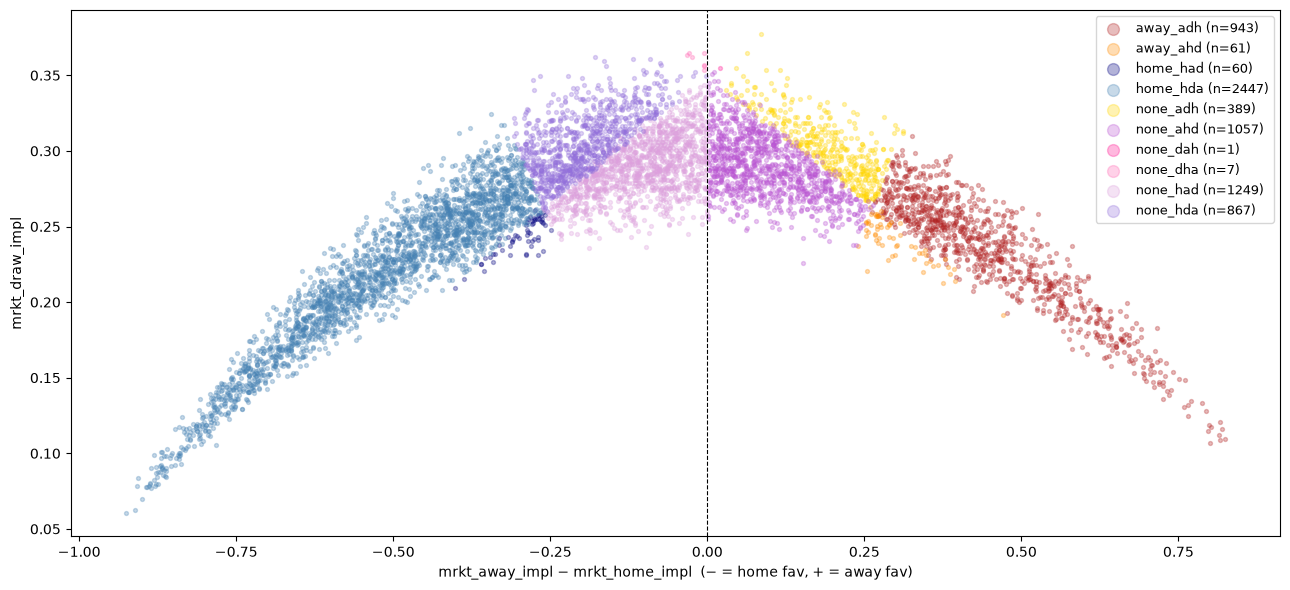

In [16]:
abt = pd.read_parquet('C:/Users/twluc/frame/01_data/03_abt/abt.parquet')

d = abt[['mrkt_home_impl', 'mrkt_draw_impl', 'mrkt_away_impl',
         'mrkt_favourite', 'mrkt_impl_order']].dropna().copy()
d['cat'] = d['mrkt_favourite'] + '_' + d['mrkt_impl_order']
d['x'] = d['mrkt_away_impl'] - d['mrkt_home_impl']

palette = {
    'home_hda': 'steelblue',
    'home_had': 'navy',
    'home_dha': 'deepskyblue',
    'none_hda': 'mediumpurple',
    'none_had': 'plum',
    'none_ahd': 'mediumorchid',
    'none_adh': 'gold',
    'none_dha': 'hotpink',
    'none_dah': 'deeppink',
    'away_adh': 'firebrick',
    'away_ahd': 'darkorange',
}


fig, ax = plt.subplots(figsize=(13, 6))
for cat, grp in d.groupby('cat'):
    ax.scatter(grp['x'], grp['mrkt_draw_impl'],
               c=palette.get(cat, 'gray'),
               label=f'{cat} (n={len(grp)})',
               alpha=0.3, s=8)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('mrkt_away_impl − mrkt_home_impl  (− = home fav, + = away fav)')
ax.set_ylabel('mrkt_draw_impl')
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()


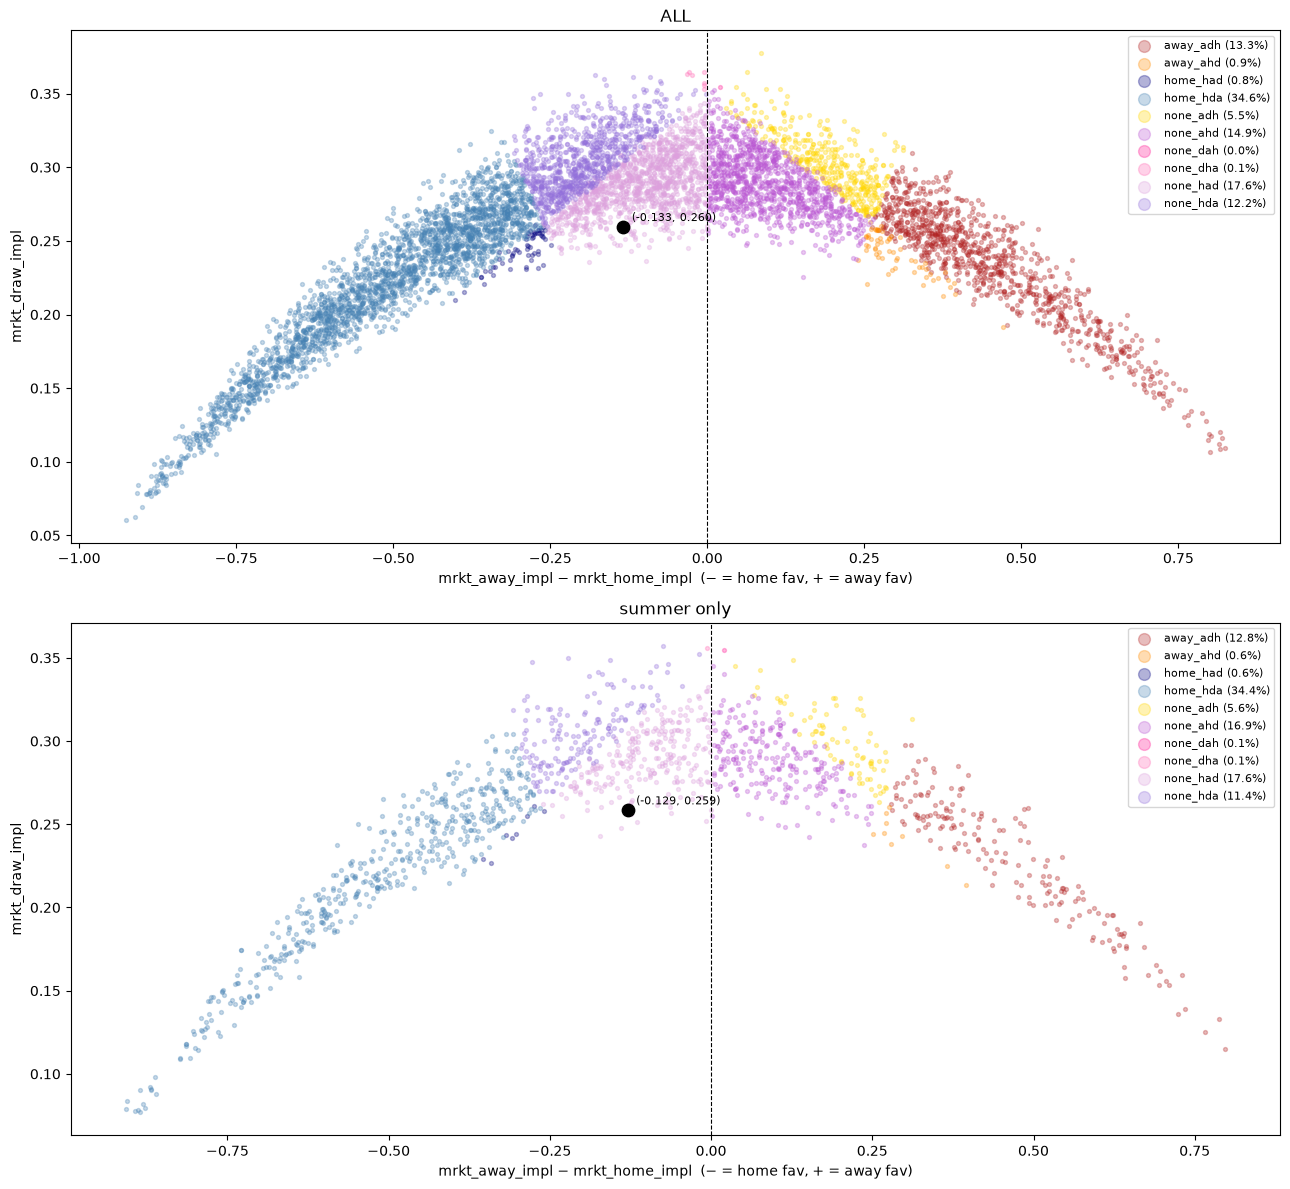

In [20]:
abt = pd.read_parquet('C:/Users/twluc/frame/01_data/03_abt/abt.parquet')

d = abt[['mrkt_home_impl', 'mrkt_draw_impl', 'mrkt_away_impl',
         'mrkt_favourite', 'mrkt_impl_order', 'season_4phase']].dropna().copy()
d['cat'] = d['mrkt_favourite'] + '_' + d['mrkt_impl_order']
d['x'] = d['mrkt_away_impl'] - d['mrkt_home_impl']

palette = {
    'home_hda': 'steelblue',    'home_had': 'navy',         'home_dha': 'deepskyblue',
    'none_hda': 'mediumpurple', 'none_had': 'plum',         'none_ahd': 'mediumorchid',
    'none_adh': 'gold',         'none_dha': 'hotpink',      'none_dah': 'deeppink',
    'away_adh': 'firebrick',    'away_ahd': 'darkorange',
}

def scatter_panel(ax, data, title):
    total = len(data)
    for cat, grp in data.groupby('cat'):
        pct = len(grp) / total * 100
        ax.scatter(grp['x'], grp['mrkt_draw_impl'],
                   c=palette.get(cat, 'gray'),
                   label=f'{cat} ({pct:.1f}%)',
                   alpha=0.3, s=8)
    cx, cy = data['x'].mean(), data['mrkt_draw_impl'].mean()
    ax.scatter(cx, cy, c='black', s=80, zorder=5)
    ax.annotate(f'({cx:.3f}, {cy:.3f})', (cx, cy),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('mrkt_away_impl − mrkt_home_impl  (− = home fav, + = away fav)')
    ax.set_ylabel('mrkt_draw_impl')
    ax.set_title(title)
    ax.legend(markerscale=3, fontsize=8)

fig, axes = plt.subplots(2, 1, figsize=(13, 12))
scatter_panel(axes[0], d, 'ALL')
scatter_panel(axes[1], d[d['season_4phase'] == 'summer'], 'summer only')
plt.tight_layout()
plt.show()


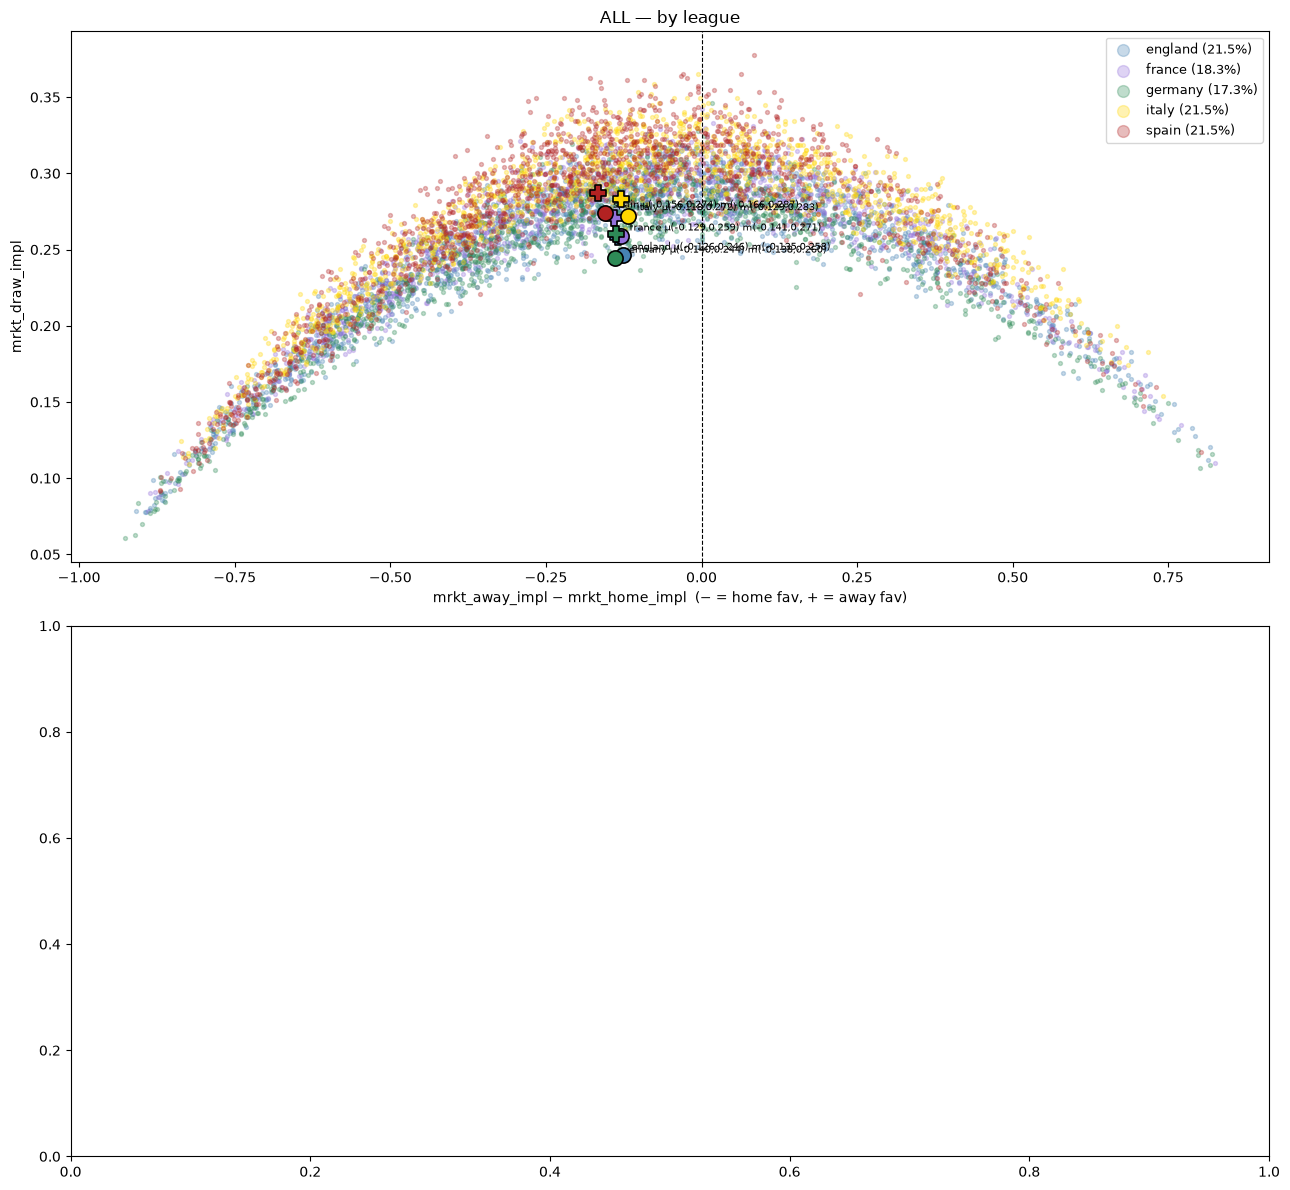

In [22]:
d2 = abt[['mrkt_home_impl', 'mrkt_draw_impl', 'mrkt_away_impl',
          'league', 'season_4phase']].dropna().copy()
d2['x'] = d2['mrkt_away_impl'] - d2['mrkt_home_impl']

league_palette = {
    'england': 'steelblue',
    'spain':   'firebrick',
    'italy':   'gold',
    'germany': 'seagreen',
    'france':  'mediumpurple',
}

def scatter_panel_league(ax, data, title):
    total = len(data)
    for league, grp in data.groupby('league'):
        pct = len(grp) / total * 100
        ax.scatter(grp['x'], grp['mrkt_draw_impl'],
                   c=league_palette[league],
                   label=f'{league} ({pct:.1f}%)',
                   alpha=0.3, s=8)
        mx, my = grp['x'].mean(),   grp['mrkt_draw_impl'].mean()
        ex, ey = grp['x'].median(), grp['mrkt_draw_impl'].median()
        ax.scatter(mx, my, c=league_palette[league], s=120, zorder=5,
                   edgecolors='black', linewidths=1.2, marker='o')
        ax.scatter(ex, ey, c=league_palette[league], s=120, zorder=5,
                   edgecolors='black', linewidths=1.2, marker='P')
        ax.annotate(f'{league} μ({mx:.3f},{my:.3f}) m({ex:.3f},{ey:.3f})', (mx, my),
                    textcoords='offset points', xytext=(6, 4), fontsize=7)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('mrkt_away_impl − mrkt_home_impl  (− = home fav, + = away fav)')
    ax.set_ylabel('mrkt_draw_impl')
    ax.set_title(title)
    ax.legend(markerscale=3, fontsize=9)

fig, axes = plt.subplots(2, 1, figsize=(13, 12))
scatter_panel_league(axes[0], d2, 'ALL — by league')
plt.tight_layout()
plt.show()
